# Strategically Robust Trajectory Optimization

Each agent plans against the *worst* deviation the other agents could make, at
every step of the horizon. This notebook compares that with two baselines:

| method | collision cost evaluated at | weight |
|---|---|---|
| **nominal** | the planned trajectory | $c_1 = 2$ |
| **wider** | the planned trajectory | $c_1 = 5$ |
| **strategically robust** | the worst case, every step | $c_1 = 2$ |

"Wider" turns the penalty up instead of changing the model. If robustness were
only extra caution, wider would reproduce it. It does not.

Every solve uses **single shooting**: the controls are the only decision
variables, and the states come from rolling the dynamics forward. Section 11
compares it with the full-space solver. The notebook runs in about two
minutes.

## 0. Setup

Makes the solver modules importable from the repository root or `notebooks/`.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / 'solvers.py').exists():          # started from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FIGDIR = ROOT / 'figures'
FIGDIR.mkdir(exist_ok=True)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import plot_style
import plotting
from costs import ALPHA, C1_NOMINAL, C1_WIDER, make_cost
from solvers import (optimize_everystep, optimize_everystep_shooting,
                     optimize_optimal, optimize_optimal_shooting, split_solution)

plot_style.apply()
pd.set_option('display.precision', 4)

# Timed repetitions for section 10.  The paper uses 30 (10 at eight agents).
# Ratios are stable at these lower counts; absolute times are not.
BENCH_RUNS = 5
BENCH_RUNS_8 = 3

### The cost

Each agent tracks its goal and pays a penalty for being near any other agent:

$$
J = \sum_i \Big[ (x_{i,H} - x_i^f)^\top Q_f (x_{i,H} - x_i^f)
  + \sum_{t<H} (x_{i,t} - x_i^f)^\top Q (x_{i,t} - x_i^f) + u_{i,t}^\top R\, u_{i,t} \Big]
  \; + \sum_{i<j} \sum_t f\big(\|p_{i,t} - p_{j,t}\|\big)
$$

The pair cost is the log barrier $f(d) = -c_1 \log(d^2 + \alpha)$. `make_cost`
returns $f$ together with $f'$. Without $f'$, SLSQP falls back to finite
differences, which is slower and tends to stop at a worse point.

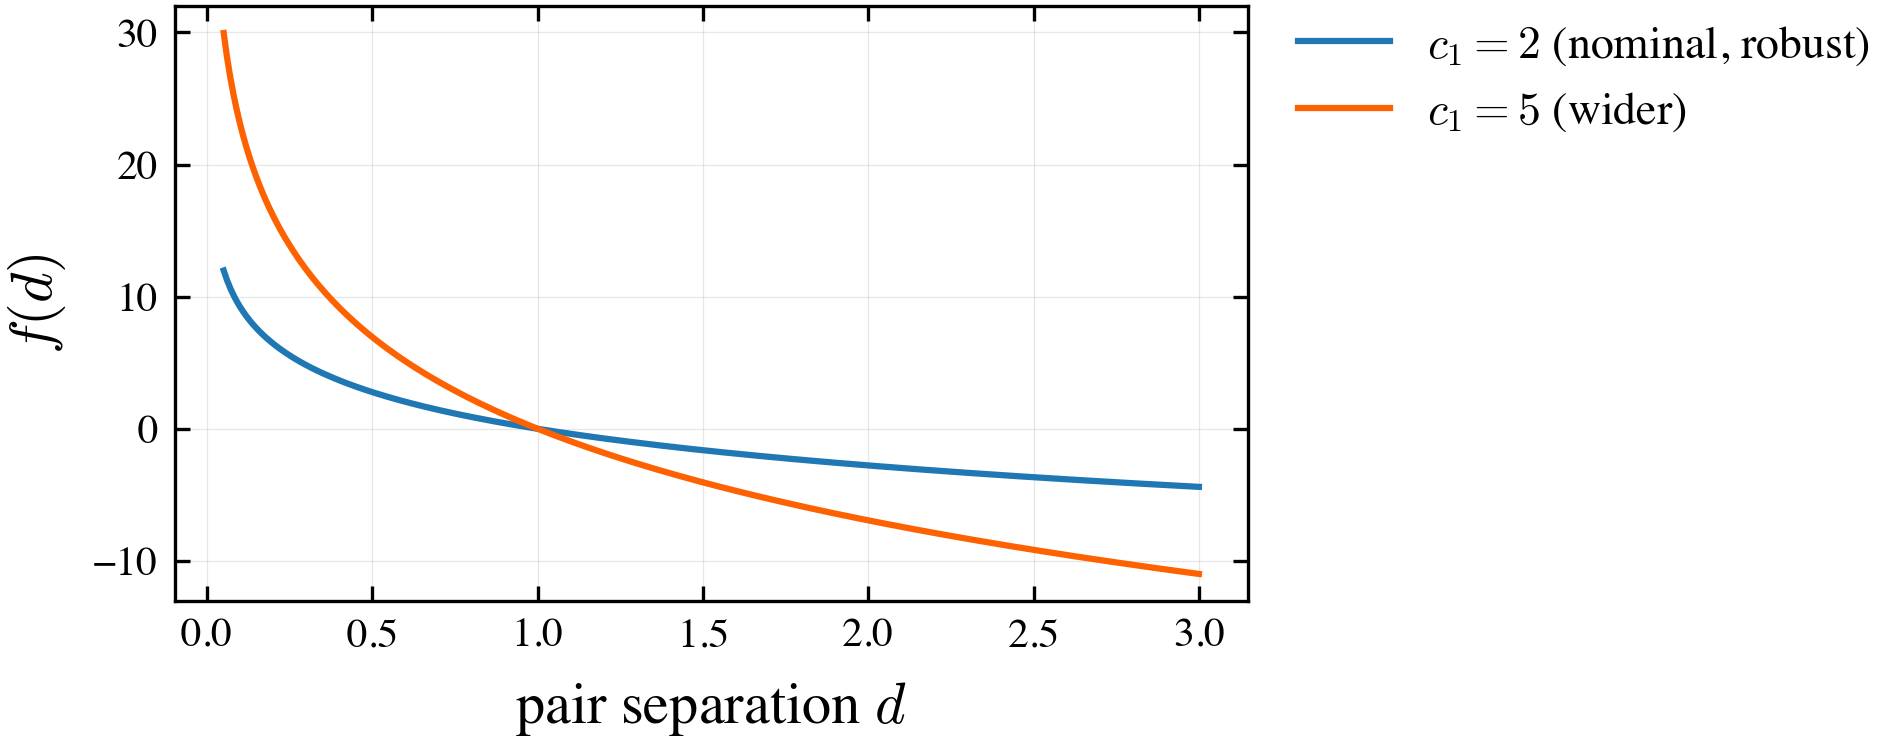

In [2]:
cost_nominal, grad_nominal = make_cost('logarithmic', c1=C1_NOMINAL, alpha=ALPHA)
cost_wider, grad_wider = make_cost('logarithmic', c1=C1_WIDER, alpha=ALPHA)

d = np.linspace(0.05, 3.0, 300)
fig, ax = plt.subplots(figsize=(plotting.PANEL * 1.3, plotting.PANEL * 0.8))
ax.plot(d, cost_nominal(d), color=plot_style.BLUE, label=f'$c_1 = {C1_NOMINAL:g}$ (nominal, robust)')
ax.plot(d, cost_wider(d), color=plot_style.ORANGE, label=f'$c_1 = {C1_WIDER:g}$ (wider)')
ax.set_xlabel('pair separation $d$')
ax.set_ylabel('$f(d)$')
ax.grid(True, linewidth=0.3, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
fig.tight_layout()
plotting.legend_right(ax, fontsize=11)
plt.show()

## 1. Head-on: two agents swap places

Single integrators ($A = I$, $B = \Delta t\, I$), horizon $H = 20$ over 2 s.
The agents start 2 apart and swap places, so their straight-line plans
collide. The $\pm 0.05$ offset in $y$ breaks the mirror symmetry, which would
otherwise leave two equally good optima for the solver to pick between.

In [3]:
H, tf, eps = 20, 2.0, 2.0
dt = tf / H
n_a, sdim, cdim, pdim = 2, 2, 2, 2

A = np.eye(sdim)
B = dt * np.eye(cdim)
Q = np.eye(sdim)
Qf = 150.0 * np.eye(sdim)
R = np.eye(cdim)

x0 = np.array([[0.0, 0.95], [2.0, 1.05]])
xf = np.array([[2.0, 1.05], [0.0, 0.95]])

problem = (x0, xf, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)
print(f'{n_a} agents, H = {H}, dt = {dt}, eps = {eps}')
print(f'full space:      {n_a * (H + 1) * sdim + n_a * H * cdim} variables, '
      f'{n_a * sdim + n_a * H * sdim} equality constraints')
print(f'single shooting: {n_a * H * cdim} variables, 0 equality constraints')

2 agents, H = 20, dt = 0.1, eps = 2.0
full space:      164 variables, 84 equality constraints
single shooting: 80 variables, 0 equality constraints


### The three solves

Wider and robust both start from the nominal solution.

In [4]:
import time

t0 = time.perf_counter()
res_nominal = optimize_optimal_shooting(*problem, cost_nominal,
                                        distance_cost_grad_func=grad_nominal)
t_nominal = time.perf_counter() - t0
x_nom, u_nom = split_solution(res_nominal, n_a, H, sdim, cdim)

t0 = time.perf_counter()
res_wider = optimize_optimal_shooting(*problem, cost_wider,
                                      distance_cost_grad_func=grad_wider, u_opt=u_nom)
t_wider = time.perf_counter() - t0

t0 = time.perf_counter()
res_robust = optimize_everystep_shooting(*problem, eps, cost_nominal,
                                         distance_cost_grad_func=grad_nominal,
                                         u_opt=u_nom)
t_robust = time.perf_counter() - t0

RESULTS = [res_nominal, res_wider, res_robust]
LABELS = ['nominal', 'wider', 'strat. robust']

pd.DataFrame([
    {'method': lab, 'objective': r.fun, 'iterations': r.nit,
     'function evals': r.nfev, 'seconds': t, 'converged': bool(r.success)}
    for lab, r, t in zip(LABELS, RESULTS, [t_nominal, t_wider, t_robust])
]).set_index('method')

,objective,iterations,function evals,seconds,converged
method,,,,,
nominal,73.3080,35,53,0.5008,True
wider,8.3905,13,23,0.0097,True
strat. robust,116.4260,12,23,0.1208,True


The objectives are **not comparable across rows**, since each method minimizes
a different function. The geometry is comparable, and the rest of the notebook
measures it.

## 2. Trajectories

Color is the agent; dash pattern is the method.

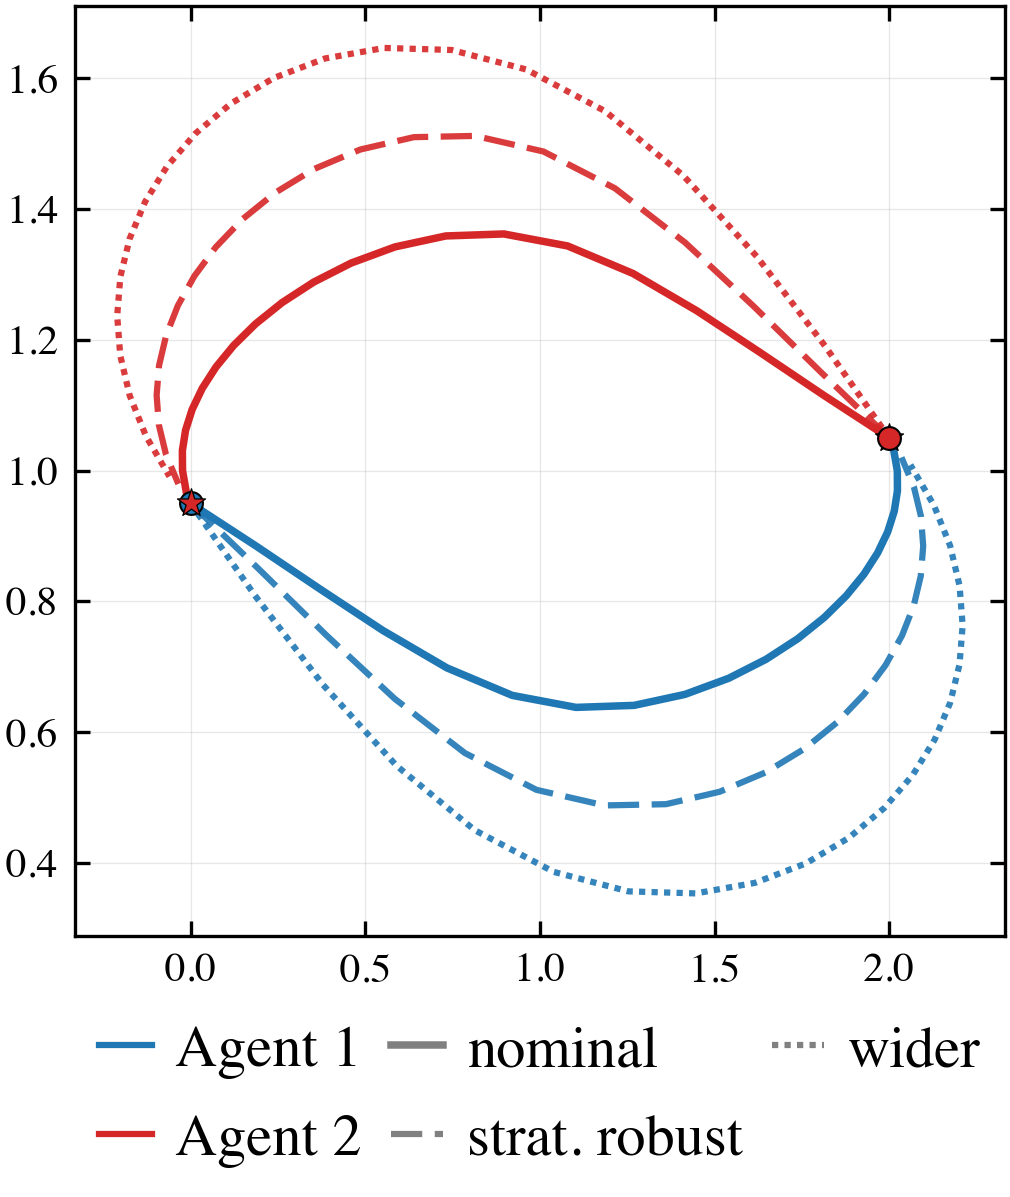

In [5]:
plotting.plot_trajectories(res_nominal, [res_robust, res_wider], n_a, H, sdim, cdim, xf,
                           method_labels=LABELS[:1] + ['strat. robust', 'wider'],
                           save_path=FIGDIR / 'headon_trajectories.png')
plt.show()

Both alternatives bow out further than nominal, and wider bows furthest. But
distance from the nominal path is not safety. Section 4 measures what each
method actually buys.

## 3. Relative coordinates

For a pair, only the relative position $z_t = x_{i,t} - x_{j,t}$ matters, and
the origin is a collision. Solid curves are the plans. Dashed curves are where
an adversary with budget $\varepsilon = 2$ can push them.

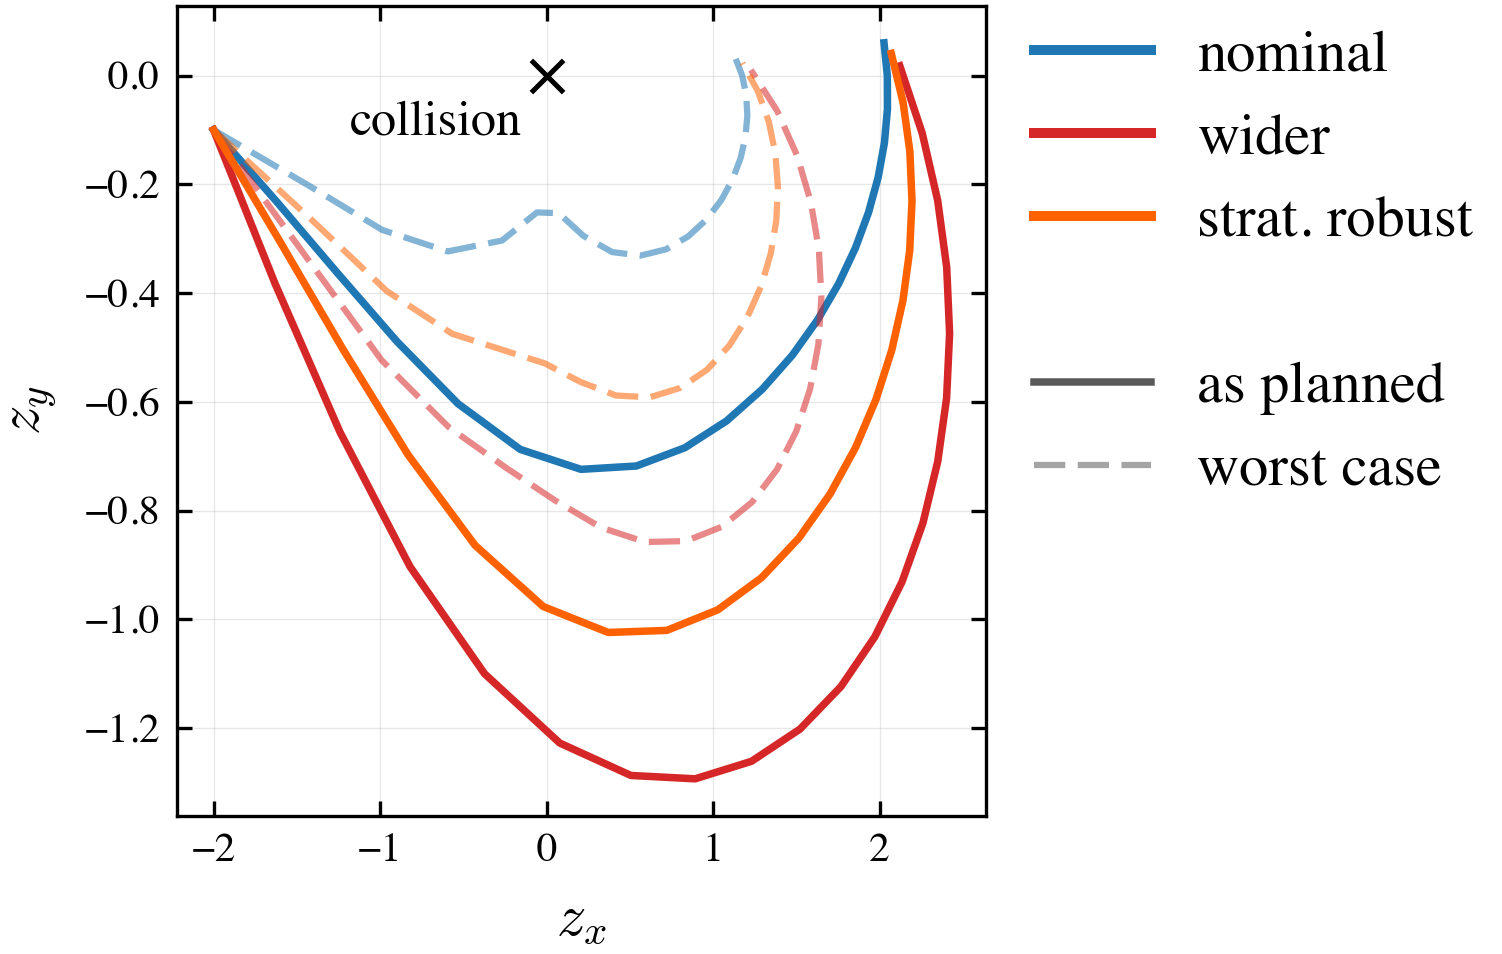

In [6]:
plotting.plot_relative_trajectory(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B,
                                  save_path=FIGDIR / 'headon_relative.png')
plt.show()

## 4. What the adversary can take away

The gap between a method's solid and dashed curves is margin the adversary can
erase. A robust plan keeps its *dashed* curve high.

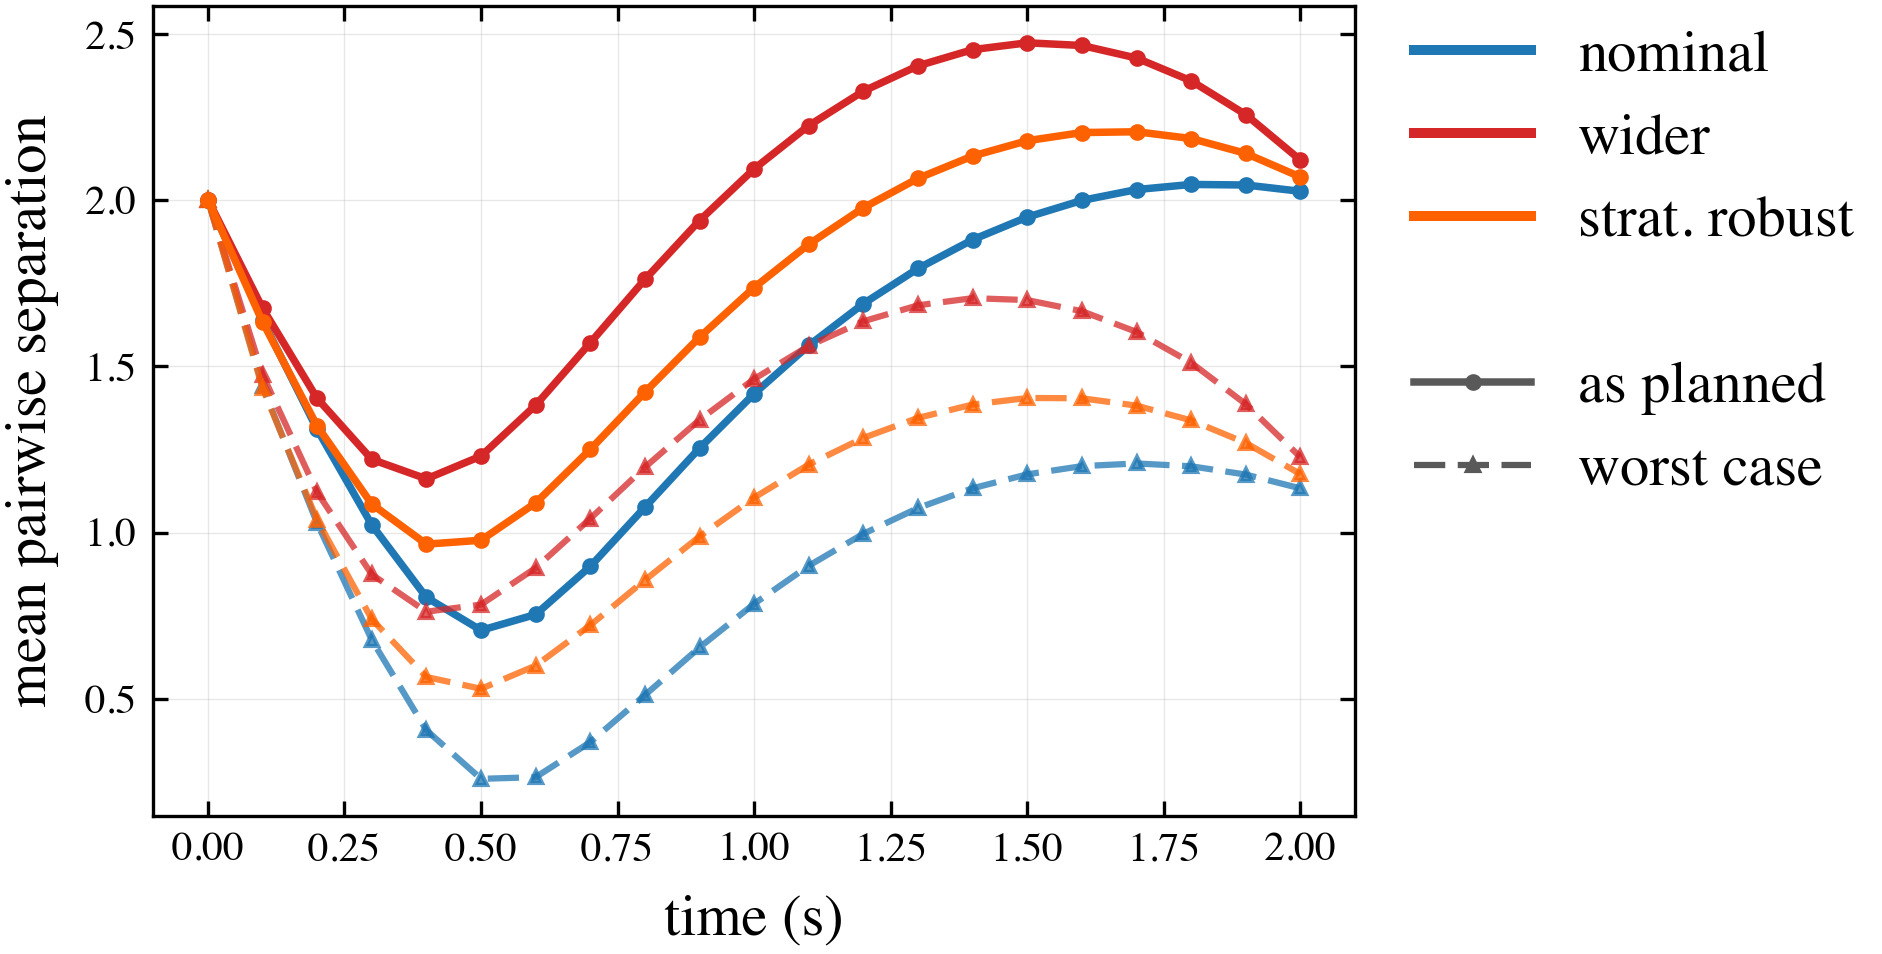

In [7]:
plotting.plot_avg_distances(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / 'headon_separation.png')
plt.show()

In [8]:
sep = pd.DataFrame(plotting.min_separation_table(
    RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
sep['worst-case margin vs nominal'] = (
    sep['min separation, worst case'] / sep.loc['nominal', 'min separation, worst case'])
sep

,min separation,"min separation, worst case",worst-case margin vs nominal
method,,,
nominal,0.7056,0.2584,1.0000
wider,1.1615,0.7615,2.9475
strat. robust,0.9649,0.5295,2.0494


## 5. Robustness is not a larger penalty

Both alternatives raise the worst case. Path deviation measures what each pays
for it: the area between a method's trajectory and the nominal one, averaged
over agents.

In [9]:
import benchmark_tables as bench

trade = []
for lab, res in zip(LABELS, RESULTS):
    x = split_solution(res, n_a, H, sdim, cdim)[0]
    trade.append({
        'method': lab,
        'path deviation': bench.integrated_path_deviation(x, x_nom, dt, pdim),
        'min separation, worst case': sep.loc[lab, 'min separation, worst case'],
    })
trade = pd.DataFrame(trade).set_index('method')
gain = trade['min separation, worst case'] - trade.loc['nominal', 'min separation, worst case']
trade['worst-case gain'] = gain
trade['gain per unit deviation'] = (gain / trade['path deviation']).replace([np.inf, -np.inf], np.nan)
trade

,path deviation,"min separation, worst case",worst-case gain,gain per unit deviation
method,,,,
nominal,0.0000,0.2584,0.0000,NaN
wider,0.5159,0.7615,0.5032,0.9754
strat. robust,0.2523,0.5295,0.2711,1.0747


Here wider buys *more* worst-case margin, at twice the path deviation. Per unit
of deviation the two are within about 10%, and section 8 shows the ordering
flips with more agents.

The lasting difference is what sets the margin. Wider's comes from $c_1$, a
tuning constant with no physical meaning. Robust's comes from $\varepsilon$,
the disturbance energy the plan must absorb, stated up front in units.

## 6. Animation

Saved as a GIF, which keeps the notebook far smaller than inline JavaScript.

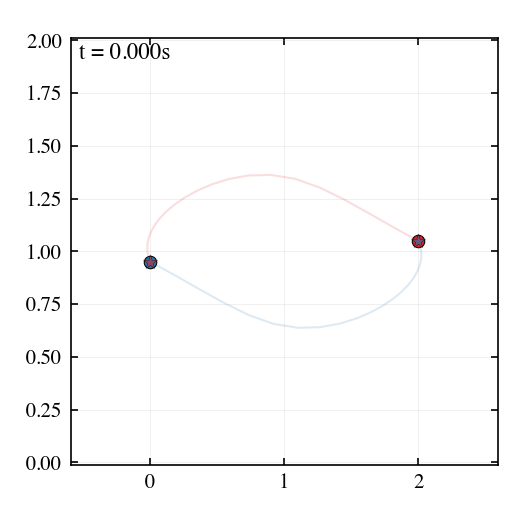

In [10]:
fig, anim = plotting.animate_trajectories(
    res_nominal, [res_robust], n_a, H, sdim, cdim, xf, dt,
    save_path=FIGDIR / 'headon_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / 'headon_animation.gif')))

## 7. Parallel: a conflict the nominal plan never sees

Two agents travel side by side, 2 apart, and never approach. The barrier is
essentially inactive and the nominal solve is easy. Give the adversary a
budget, though, and a conflict appears that the nominal model cannot express.

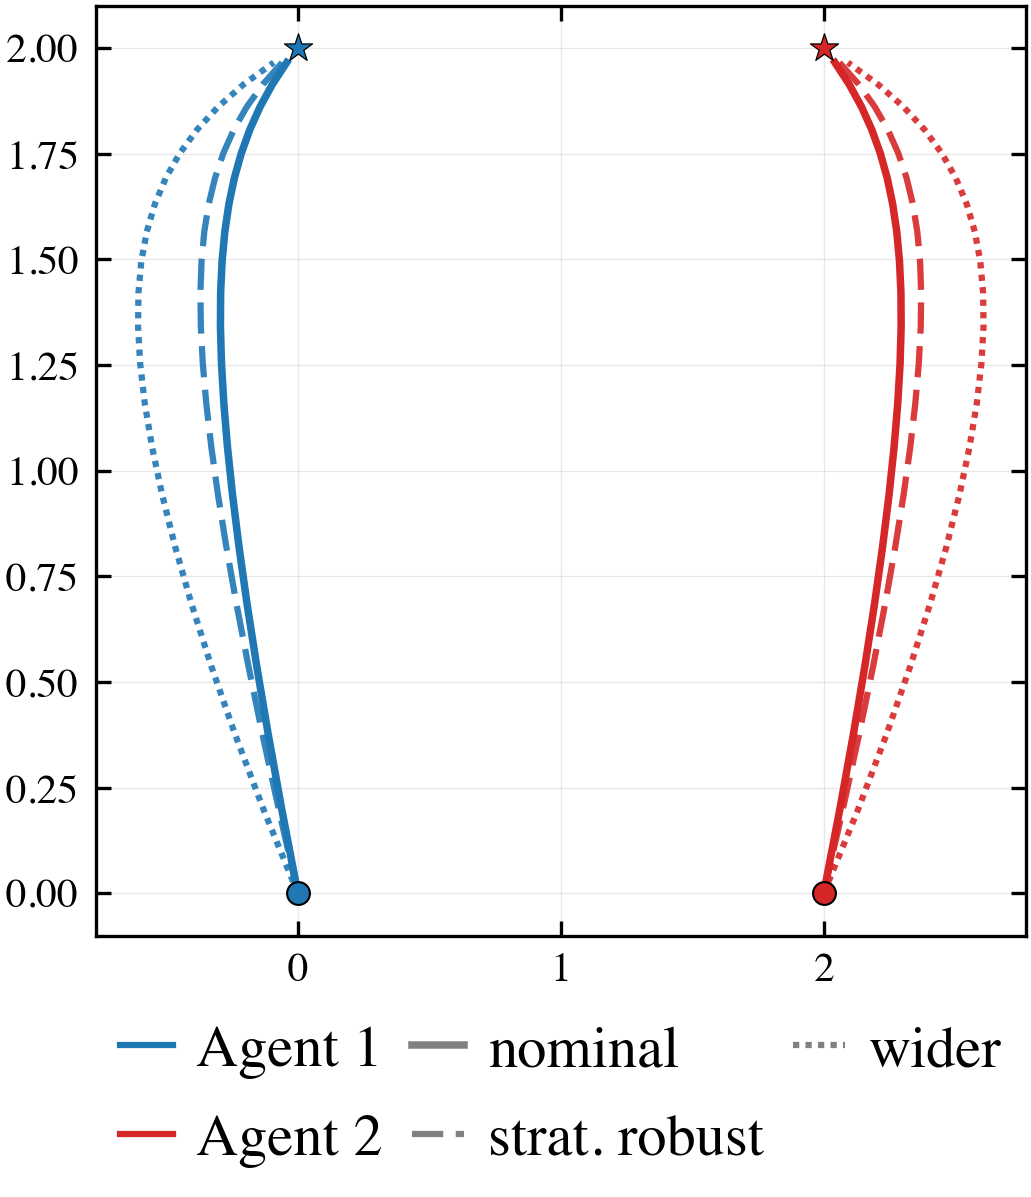

In [11]:
x0_par = np.array([[0.0, 0.0], [2.0, 0.0]])
xf_par = np.array([[0.0, 2.0], [2.0, 2.0]])
problem_par = (x0_par, xf_par, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)

res_par_nominal = optimize_optimal_shooting(*problem_par, cost_nominal,
                                            distance_cost_grad_func=grad_nominal)
x_par_nom, u_par_nom = split_solution(res_par_nominal, n_a, H, sdim, cdim)
res_par_wider = optimize_optimal_shooting(*problem_par, cost_wider,
                                          distance_cost_grad_func=grad_wider,
                                          u_opt=u_par_nom)
res_par_robust = optimize_everystep_shooting(*problem_par, eps, cost_nominal,
                                             distance_cost_grad_func=grad_nominal,
                                             u_opt=u_par_nom)
RESULTS_PAR = [res_par_nominal, res_par_wider, res_par_robust]

plotting.plot_trajectories(res_par_nominal, [res_par_robust, res_par_wider],
                           n_a, H, sdim, cdim, xf_par,
                           method_labels=['nominal', 'strat. robust', 'wider'],
                           save_path=FIGDIR / 'parallel_trajectories.png')
plt.show()

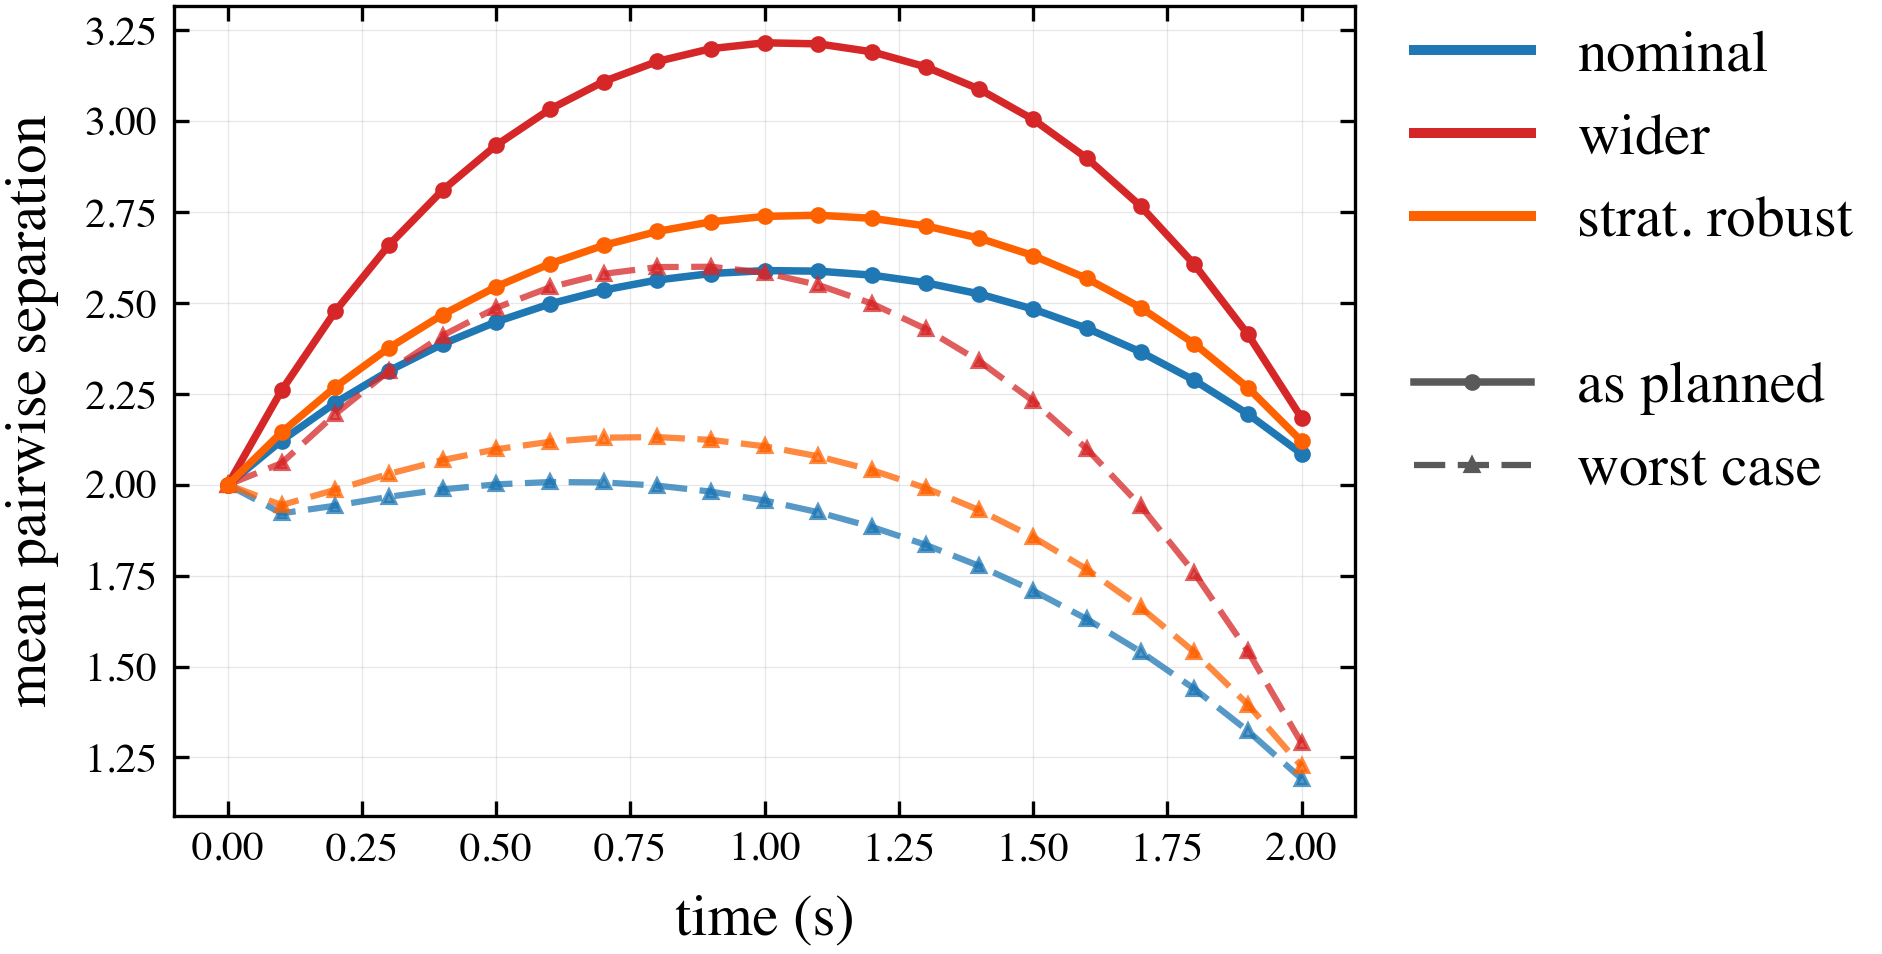

,min separation,"min separation, worst case",path deviation,worst-case gain,gain per unit deviation
method,,,,,
nominal,2.0,1.1911,0.0000,0.0000,NaN
wider,2.0,1.2894,0.4488,0.0984,0.2192
strat. robust,2.0,1.2255,0.1091,0.0344,0.3155


In [12]:
plotting.plot_avg_distances(RESULTS_PAR, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / 'parallel_separation.png')
plt.show()

sep_par = pd.DataFrame(plotting.min_separation_table(
    RESULTS_PAR, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
sep_par['path deviation'] = [
    bench.integrated_path_deviation(split_solution(r, n_a, H, sdim, cdim)[0],
                                    x_par_nom, dt, pdim) for r in RESULTS_PAR]
gain_par = (sep_par['min separation, worst case']
            - sep_par.loc['nominal', 'min separation, worst case'])
sep_par['worst-case gain'] = gain_par
sep_par['gain per unit deviation'] = (
    gain_par / sep_par['path deviation']).replace([np.inf, -np.inf], np.nan)
sep_par

`min separation` is 2.0 for every method: the agents are never closer than at
the start. Every difference lives in the worst-case column. The nominal planner
is not careless, since by its own model there is no conflict.

Wider again buys more absolute margin at several times the deviation. Per unit
of deviation, though, robust now leads by far more than the ~10% seen head-on.

The easy nominal solve also explains this scenario's high runtime ratio in
section 10. The ratio is roughly `1 + robust_iterations / nominal_iterations`,
and here the nominal count is small.

## 8. Four agents

Six pairs, and each agent must resolve conflicts with several neighbours at
once. Only the scenario changes.

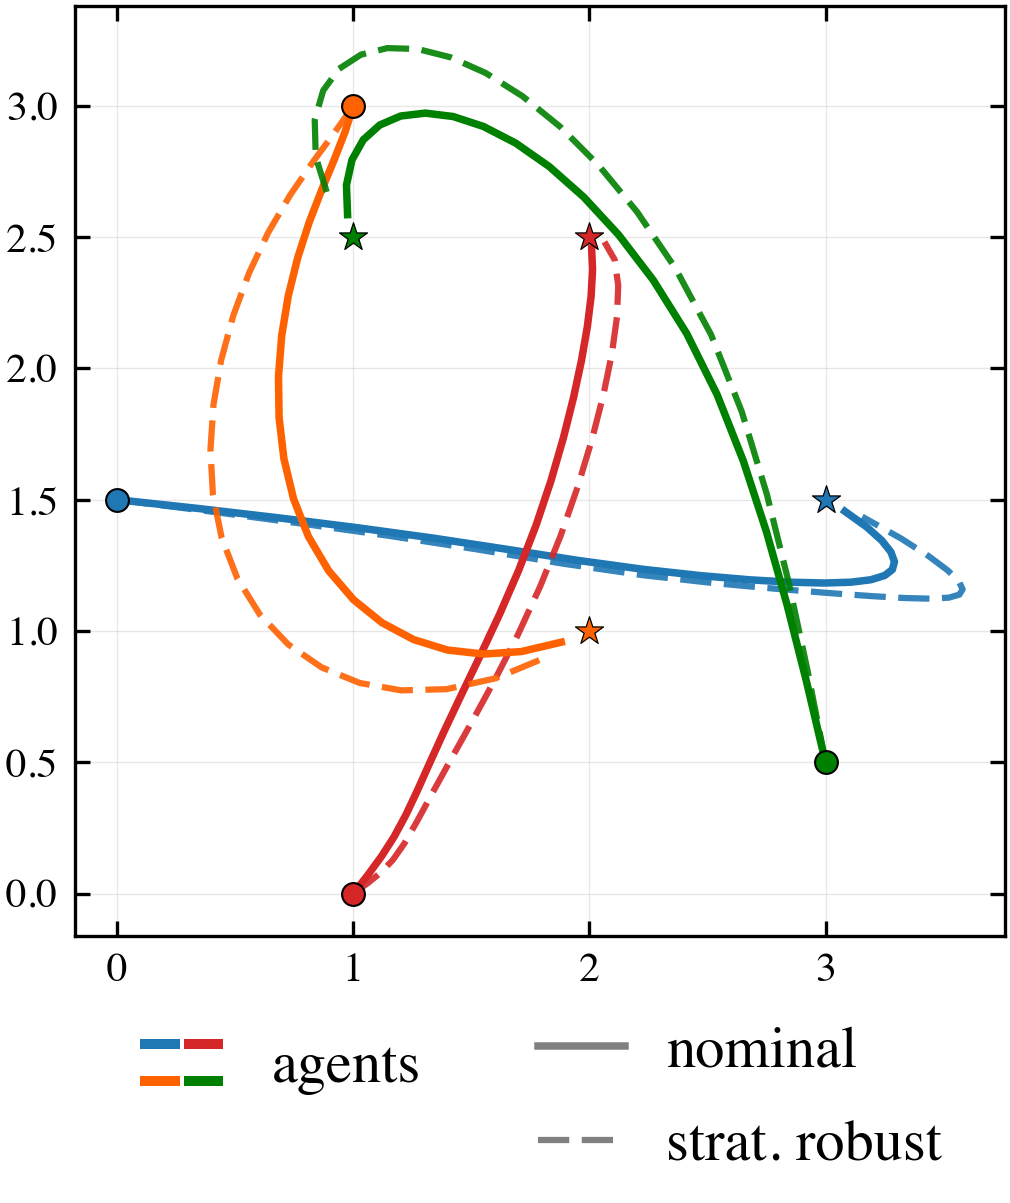

In [13]:
n_a4 = 4
x0_4 = np.array([[0.0, 1.5], [1.0, 0.0], [1.0, 3.0], [3.0, 0.5]])
xf_4 = np.array([[3.0, 1.5], [2.0, 2.5], [2.0, 1.0], [1.0, 2.5]])
problem4 = (x0_4, xf_4, A, B, H, Q, R, Qf, n_a4, sdim, cdim, pdim)

res4_nominal = optimize_optimal_shooting(*problem4, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
x4_nom, u4_nom = split_solution(res4_nominal, n_a4, H, sdim, cdim)
res4_wider = optimize_optimal_shooting(*problem4, cost_wider,
                                       distance_cost_grad_func=grad_wider, u_opt=u4_nom)
res4_robust = optimize_everystep_shooting(*problem4, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u4_nom)
RESULTS4 = [res4_nominal, res4_wider, res4_robust]

# Wider is left off the plot (twelve more curves); the tables below include it.
plotting.plot_trajectories(res4_nominal, [res4_robust], n_a4, H, sdim, cdim, xf_4,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '4agent_trajectories.png')
plt.show()

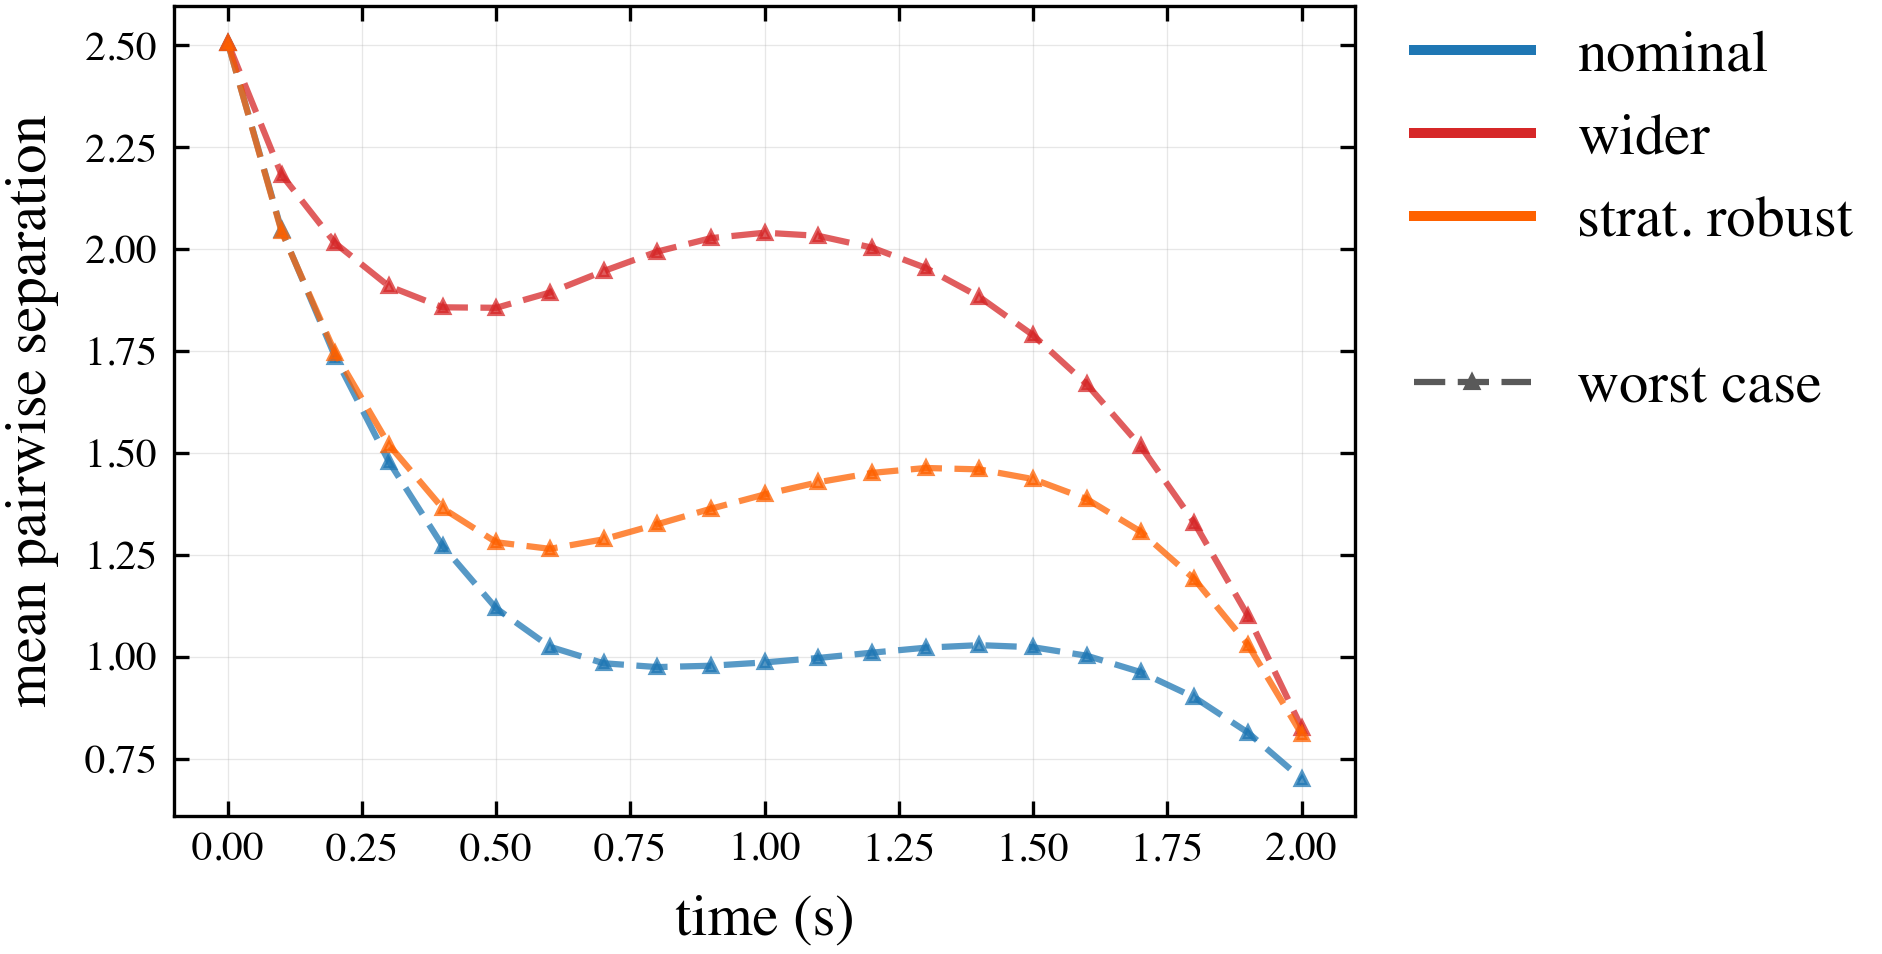

,min separation,"min separation, worst case"
method,,
nominal,0.9652,0.1470
wider,1.1153,0.2209
strat. robust,1.0753,0.2790


In [14]:
plotting.plot_avg_distances(RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B, dt,
                            show_nominal=False,
                            save_path=FIGDIR / '4agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

The plot and the table disagree. On **mean** worst-case separation, wider sits
well above robust. On the **minimum** over all pairs and steps, which is what a
safety claim rests on, robust wins, with less than half the path deviation.

Averaging lets slack in five pairs hide a tight sixth. Wider pushes every pair
apart, including pairs that were never in danger. Robust spends its deviation
where the adversary would attack.

## 9. Eight agents on a circle

Eight agents on a circle of radius 2 each head for the opposite point. Every
straight-line plan passes through the centre, so all 28 pairs conflict at once.
Warm-started, the robust solve is *faster* than the nominal solve it starts
from.

In [15]:
n_a8 = 8
angles = np.linspace(0, 2 * np.pi, n_a8, endpoint=False)
centre, radius = np.array([2.0, 2.0]), 2.0
x0_8 = np.array([centre + radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
xf_8 = np.array([centre - radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
problem8 = (x0_8, xf_8, A, B, H, Q, R, Qf, n_a8, sdim, cdim, pdim)

t0 = time.perf_counter()
res8_nominal = optimize_optimal_shooting(*problem8, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
t8_nominal = time.perf_counter() - t0
x8_nom, u8_nom = split_solution(res8_nominal, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust = optimize_everystep_shooting(*problem8, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u8_nom)
t8_robust = time.perf_counter() - t0

print(f'nominal: {t8_nominal:6.2f}s   robust (warm-started): {t8_robust:6.2f}s')

nominal:   2.10s   robust (warm-started):   0.94s


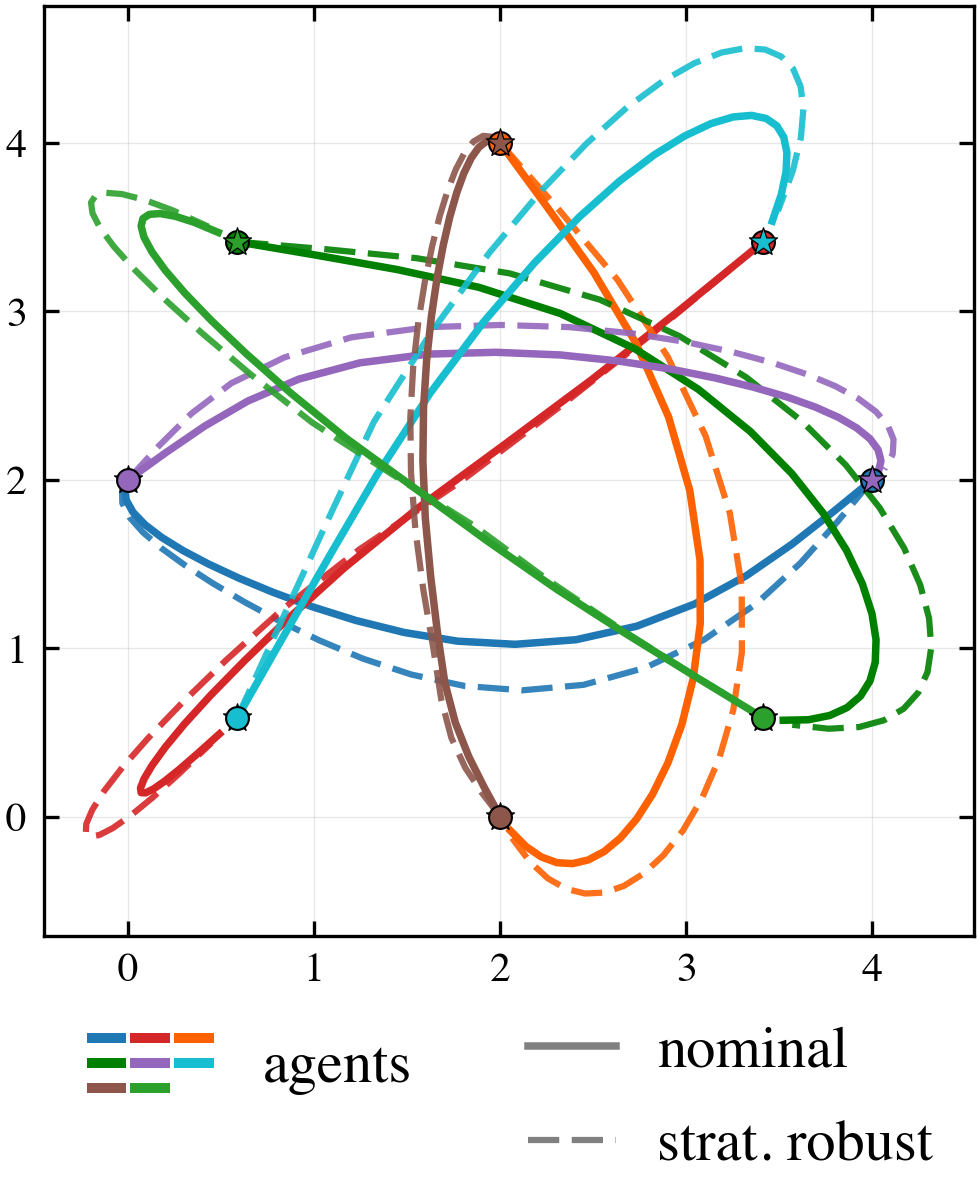

In [16]:
plotting.plot_trajectories(res8_nominal, [res8_robust], n_a8, H, sdim, cdim, xf_8,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '8agent_trajectories.png')
plt.show()

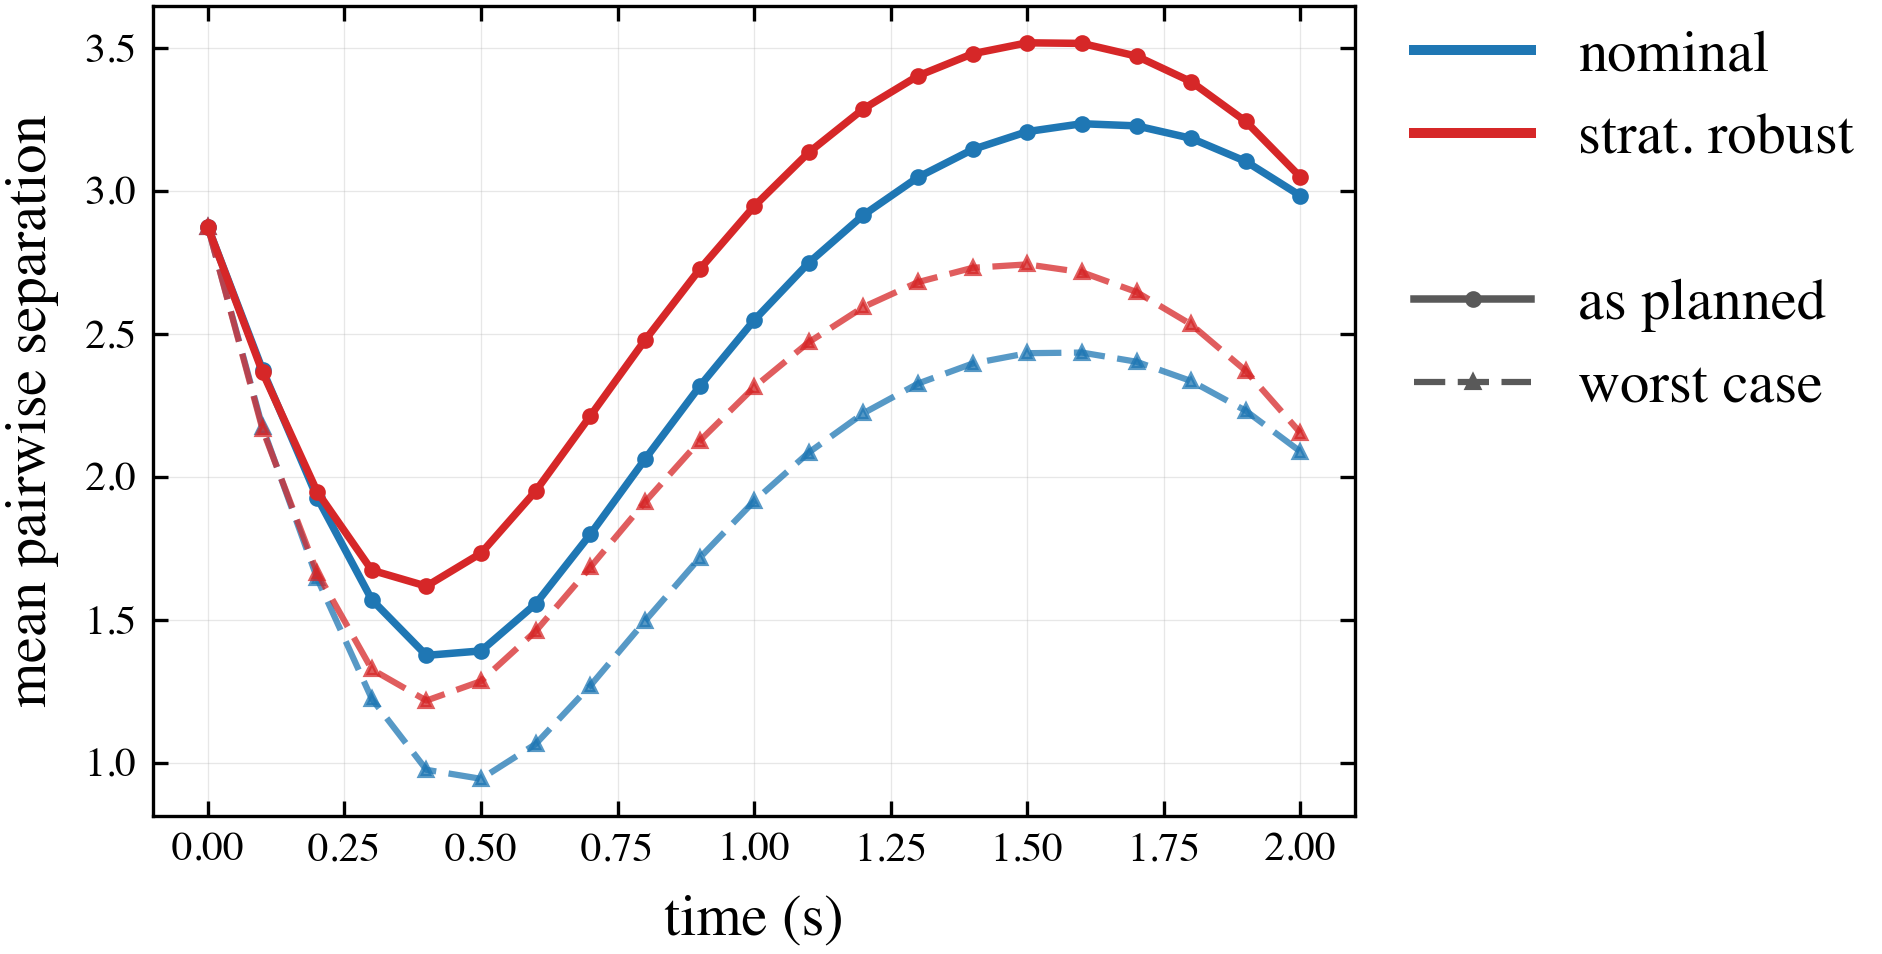

,min separation,"min separation, worst case"
method,,
nominal,0.4214,0.0214
strat. robust,0.5879,0.2347


In [17]:
plotting.plot_avg_distances([res8_nominal, res8_robust], ['nominal', 'strat. robust'],
                            n_a8, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / '8agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    [res8_nominal, res8_robust], ['nominal', 'strat. robust'],
    n_a8, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

## 10. Runtime

`benchmark_tables.py` produces the paper's timing tables. It follows three
rules, each learned from a measurement that turned out wrong:

1. **Analytic gradients for every method.** A finite-difference baseline once
   stopped early at a worse optimum and inflated the 8-agent robust overhead
   from 1.29x to 3.72x.
2. **Median next to mean.** One outlier moved the 4-agent ratio from 1.89x to
   1.72x under the mean. The CV column flags noisy rows.
3. **One optimum per cell.** If the runs land on different local minima, the
   timing spread is not machine noise. The `uniq` column must be 1.

The robust time includes its nominal initialization, so the ratio is the full
cost of switching methods. `USE_SHOOTING` matches this notebook's solver.
Some ratios run higher than in the README's full-space table, where a
constrained QP that both methods share dominates each iteration and hides the
robust cost.

In [18]:
bench.USE_SHOOTING = True

results_bench = [bench.run_scenario(name, BENCH_RUNS, verbose=False)
                 for name in ('Head-on', 'Parallel', '4 agents')]
results_bench.append(bench.run_scenario('8 agents', BENCH_RUNS_8, verbose=False))

rows = []
for r in results_bench:
    s = bench.summarize(r)
    for method in ('nominal', 'wider', 'robust'):
        rows.append({
            'scenario': r['scenario'], 'n_a': r['n_a'],
            'method': bench.LABEL[method],
            'median (s)': s[method]['median'],
            'ratio': s[method]['ratio_median'],
            'CV': s[method]['cv'],
            'iterations': s[method]['nit'],
            'path deviation': r['deviation'][method],
            'objective': s[method]['objective'],
            'uniq': s[method]['objective_unique'],
        })
runtime = pd.DataFrame(rows).set_index(['scenario', 'method'])
runtime

n_a  median (s)   ratio      CV  iterations  \
scenario method                                                       
Head-on  Nominal          2      0.0249  1.0000  0.0258        35.0   
         Wider            2      0.0270  1.0855  0.0145        38.0   
         Strat. Robust    2      0.0348  1.4012  0.0133        12.0   
Parallel Nominal          2      0.0067  1.0000  0.0052         9.0   
         Wider            2      0.0075  1.1062  0.0053        10.0   
         Strat. Robust    2      0.0139  2.0660  0.0043         8.0   
4 agents Nominal          4      0.0806  1.0000  0.0086        25.0   
         Wider            4      0.0846  1.0498  0.0145        26.0   
         Strat. Robust    4      0.1561  1.9361  0.0101        20.0   
8 agents Nominal          8      2.0945  1.0000  0.0007        92.0   
         Wider            8      2.2978  1.0971  0.0006       101.0   
         Strat. Robust    8      3.0336  1.4484  0.0017        37.0   

                        path deviation  objective  uniq  
scenario method                                          
Head-on  Nominal                0.0000    73.3080     1  
         Wider                  0.5159     8.3905     1  
         Strat. Robust          0.2523   116.4260     1  
Parallel Nominal                0.0000    20.2524     1  
         Wider                  0.4488  -100.3461     1  
         Strat. Robust          0.1091    46.5736     1  
4 agents Nominal                0.0000   181.0621     1  
         Wider                  0.9532  -348.5486     1  
         Strat. Robust          0.4048   428.1921     1  
8 agents Nominal                0.0000    36.6866     1  
         Wider                  1.3681 -3389.7336     1  
         Strat. Robust          0.4109   884.7809     1

The headline is the `ratio` on the **Strat. Robust** rows: the end-to-end cost
of robustness as a multiple of nominal runtime.

In [19]:
print(bench.format_tables(results_bench, stat='median'))


### Head-on  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
---------------------------------------------------------------------------------------------
Nominal           0.0251   0.0249  0.0006  2.6%    35   1.00x     0.0000       73.3080     1
Wider             0.0270   0.0270  0.0004  1.4%    38   1.09x     0.5159        8.3905     1
Strat. Robust     0.0350   0.0348  0.0005  1.3%    12   1.40x     0.2523      116.4260     1

wall breakdown  measured overhead   total  share  per run
Nominal             0.13     0.05    0.18 33.4%    0.025
Wider               0.14     0.02    0.15 29.4%    0.027
Strat. Robust       0.17     0.02    0.20 37.2%    0.035
scenario total      0.44     0.09    0.53                  (unattributed +0.00s)

### Parallel  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
-----------------

## 11. Full space vs single shooting

The full-space solver keeps $x$ and $u$ as decision variables and enforces the
dynamics as equality constraints, 336 of them at eight agents. Its default
initial guess differs from shooting's, and at eight agents the two reach
different optima, so compare objectives alongside times.

In [20]:
t0 = time.perf_counter()
res8_nominal_f = optimize_optimal(*problem8, cost_nominal,
                                  distance_cost_grad_func=grad_nominal)
t8_nominal_f = time.perf_counter() - t0
x8_nom_f, u8_nom_f = split_solution(res8_nominal_f, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust_f = optimize_everystep(*problem8, eps, cost_nominal,
                                   distance_cost_grad_func=grad_nominal,
                                   x_opt=x8_nom_f, u_opt=u8_nom_f)
t8_robust_f = time.perf_counter() - t0

pd.DataFrame([
    {'method': 'nominal', 'parameterization': 'single shooting',
     'seconds': t8_nominal, 'objective': res8_nominal.fun, 'iterations': res8_nominal.nit},
    {'method': 'nominal', 'parameterization': 'full space',
     'seconds': t8_nominal_f, 'objective': res8_nominal_f.fun, 'iterations': res8_nominal_f.nit},
    {'method': 'strat. robust', 'parameterization': 'single shooting',
     'seconds': t8_robust, 'objective': res8_robust.fun, 'iterations': res8_robust.nit},
    {'method': 'strat. robust', 'parameterization': 'full space',
     'seconds': t8_robust_f, 'objective': res8_robust_f.fun, 'iterations': res8_robust_f.nit},
]).set_index(['method', 'parameterization'])

seconds  objective  iterations
method        parameterization                                
nominal       single shooting    2.1012    36.6866          92
              full space        41.8406    48.3576         131
strat. robust single shooting    0.9436   884.7809          37
              full space        10.2226   902.5395          32

The full-space nominal solve is an order of magnitude slower and stops at a
worse optimum. Its robust solve inherits that start, which is why the README's
full-space robust margin at eight agents is lower than section 9's.

---

**Further reading.** `adversary.py` documents the closed-form worst case. The
`README.md` appendix shows why the adversary's response drops out of the
gradient (the envelope theorem), which the paper does not derive.